<a href="https://colab.research.google.com/github/tejaswipriya22/Tejaswi_Ml-on-big-data/blob/main/Week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark scikit-learn matplotlib seaborn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

from pyspark.ml.functions import vector_to_array

from sklearn.metrics import confusion_matrix

In [3]:
spark = SparkSession.builder \
    .appName("Email Spam Classification") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


In [4]:
print("Upload emails.csv")

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

print("Uploaded:", file_name)

Upload emails.csv


Saving emails.csv to emails.csv
Uploaded: emails.csv


In [5]:
import re

# Load dataset
df = spark.read.csv(
    file_name,
    header=True,
    inferSchema=True
)

# Rename all columns: remove spaces, dots, and COMMAS which cause Spark ML issues
new_columns = [re.sub(r'[ .,]', '_', c) for c in df.columns]
df = df.toDF(*new_columns)

print("Rows:", df.count())
print("Columns:", len(df.columns))

df.show(5)

Rows: 5172
Columns: 3002
+---------+---+---+---+---+---+---+---+---+---+---+---+---+----+-----+---+---+----+----+----+----+----+---+---+---+---+---+---+---+---+----+---+---+---+---+----+---+-----+---+------+---+---+---+---+----+---+---+---+---+---+----+----+---+---------+---+---+---+---+---+-----+------+---+---+---+---+---+---+-----+-----+-----+---+----+-------+---+-----+---+---+-----+---+----+---+------+--------+---+-----------+----+-------+---+----+---+---+----+----+----+---+------+----+--------+-----+-----+----+------+------+-----+-----+---+------+---+---------+---+-----+-------+---+---+---+-----+----+----+-----+----+----+----+------+-----+----+----+---+----+---+---------+---+----------+----+----+----+----+--------+----+-----+---+------+---+---+-----+----+---+------+-----+-------+----+----+----+----------+------+---+-----+------+----+---+---+-----+------+--------+----+---+-------+----+-------+----+----+-----+---+-----+-----+---+---+---+---+-----+----------+---+----+---+----+-----+--

In [6]:
df.printSchema()

# Selecting only a subset of columns for describe to avoid the AnalysisException caused by 3000+ columns
subset_cols = ["Prediction"] + df.columns[1:11]
df.select(subset_cols).describe().show()

print("Spam and Ham Distribution")
df.groupBy("Prediction").count().show()

root
 |-- Email_No_: string (nullable = true)
 |-- the: integer (nullable = true)
 |-- to: integer (nullable = true)
 |-- ect: integer (nullable = true)
 |-- and: integer (nullable = true)
 |-- for: integer (nullable = true)
 |-- of: integer (nullable = true)
 |-- a: integer (nullable = true)
 |-- you: integer (nullable = true)
 |-- hou: integer (nullable = true)
 |-- in: integer (nullable = true)
 |-- on: integer (nullable = true)
 |-- is: integer (nullable = true)
 |-- this: integer (nullable = true)
 |-- enron: integer (nullable = true)
 |-- i: integer (nullable = true)
 |-- be: integer (nullable = true)
 |-- that: integer (nullable = true)
 |-- will: integer (nullable = true)
 |-- have: integer (nullable = true)
 |-- with: integer (nullable = true)
 |-- your: integer (nullable = true)
 |-- at: integer (nullable = true)
 |-- we: integer (nullable = true)
 |-- s: integer (nullable = true)
 |-- are: integer (nullable = true)
 |-- it: integer (nullable = true)
 |-- by: integer (nullabl

In [7]:
df = df.dropna()

print("Rows after cleaning:", df.count())

Rows after cleaning: 5172


In [9]:
# Identify only the numeric word frequency columns
# We exclude 'Email_No_' (string) and 'Prediction' (label)
all_word_cols = [c for c in df.columns if c not in ["Email_No_", "Prediction"]]

# Limit to the first 500 words to ensure performance
feature_columns = all_word_cols[:500]

# Drop 'features' column if it already exists to avoid duplication
if "features" in df.columns:
    df = df.drop("features")

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

# Transform the data
email_df = assembler.transform(df)
email_df = email_df.select("Prediction", "features")

print(f"VectorAssembler complete using {len(feature_columns)} features.")
email_df.show(5)

VectorAssembler complete using 500 features.
+----------+--------------------+
|Prediction|            features|
+----------+--------------------+
|         0|(500,[2,6,11,14,2...|
|         0|(500,[0,1,2,3,4,5...|
|         0|(500,[2,6,9,10,14...|
|         0|(500,[1,2,4,5,6,7...|
|         0|(500,[0,1,2,3,4,5...|
+----------+--------------------+
only showing top 5 rows


In [10]:
train_data, test_data = email_df.randomSplit([0.8,0.2], seed=42)

print("Training:", train_data.count())
print("Testing :", test_data.count())

Training: 4194
Testing : 978


In [11]:
# Repartition the data to handle memory pressure from high-dimensional features
train_data_repartitioned = train_data.repartition(10)

nb = NaiveBayes(
    labelCol="Prediction",
    featuresCol="features",
    modelType="multinomial"
)

# Fit the model using the repartitioned data
model = nb.fit(train_data_repartitioned)
print("Model training complete.")

Model training complete.


In [12]:
predictions = model.transform(test_data)

predictions.select(
    "Prediction",
    "prediction",
    "probability"
).show(20, truncate=False)

+----------+----------+-----------------------------+
|Prediction|prediction|probability                  |
+----------+----------+-----------------------------+
|0.0       |0.0       |[1.0,0.0]                    |
|0.0       |0.0       |[1.0,7.664136729361714E-217] |
|0.0       |0.0       |[1.0,2.610663771321961E-150] |
|0.0       |0.0       |[1.0,1.0786727310346386E-120]|
|1.0       |1.0       |[2.7155272878813007E-50,1.0] |
|0.0       |0.0       |[1.0,4.18147692968011E-88]   |
|1.0       |1.0       |[2.4735188682955335E-45,1.0] |
|0.0       |0.0       |[1.0,5.39209534059715E-124]  |
|0.0       |0.0       |[1.0,4.213745104118264E-40]  |
|0.0       |0.0       |[1.0,6.618547198431625E-113] |
|0.0       |0.0       |[1.0,5.623051405109191E-46]  |
|0.0       |0.0       |[1.0,3.9700553888430955E-47] |
|0.0       |0.0       |[1.0,2.7773217490687184E-167]|
|0.0       |0.0       |[1.0,3.426090942600087E-53]  |
|0.0       |0.0       |[1.0,4.2650494039373247E-106]|
|0.0       |0.0       |[1.0,

In [13]:
accuracy = MulticlassClassificationEvaluator(
    labelCol="Prediction",
    predictionCol="prediction",
    metricName="accuracy"
)

acc = accuracy.evaluate(predictions)

print("Accuracy =", acc)

Accuracy = 1.0


In [14]:
precision = MulticlassClassificationEvaluator(
    labelCol="Prediction",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

print("Precision =", precision.evaluate(predictions))

Precision = 1.0


In [15]:
recall = MulticlassClassificationEvaluator(
    labelCol="Prediction",
    predictionCol="prediction",
    metricName="weightedRecall"
)

print("Recall =", recall.evaluate(predictions))

Recall = 1.0


In [16]:
f1 = MulticlassClassificationEvaluator(
    labelCol="Prediction",
    predictionCol="prediction",
    metricName="f1"
)

print("F1 Score =", f1.evaluate(predictions))

F1 Score = 1.0


In [17]:
prob = predictions.withColumn(
    "prob",
    vector_to_array("probability")[1]
)

evaluator = BinaryClassificationEvaluator(
    labelCol="Prediction",
    rawPredictionCol="prob",
    metricName="areaUnderROC"
)

roc = evaluator.evaluate(prob)

print("ROC-AUC =", roc)

ROC-AUC = 1.0


In [18]:
pred_pd = predictions.select(
    "Prediction",
    "prediction"
).toPandas()

cm = confusion_matrix(
    pred_pd["Prediction"],
    pred_pd["prediction"]
)

print(cm)

[[653   0]
 [  0 325]]


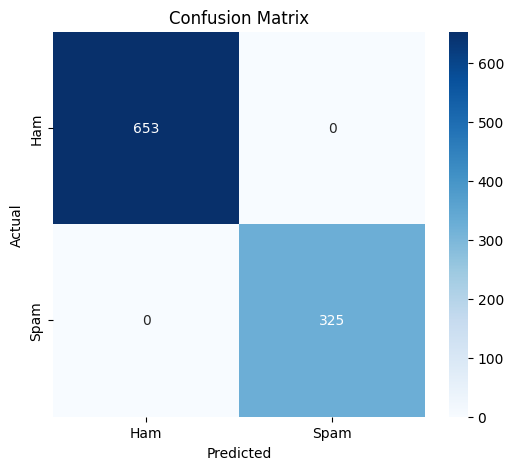

In [19]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [20]:
theta = model.theta.toArray()

spam_weights = theta[1]

importance = pd.DataFrame({
    "Word": feature_columns,
    "Weight": spam_weights
})

importance = importance.sort_values(
    by="Weight",
    ascending=False
)

importance.head(20)

,Word,Weight
40,e,-2.448145
54,t,-2.765474
6,a,-2.809218
138,o,-2.818419
14,i,-2.855785
275,n,-2.954477
173,r,-2.968355
23,s,-3.037752
72,l,-3.395697
140,c,-3.470995


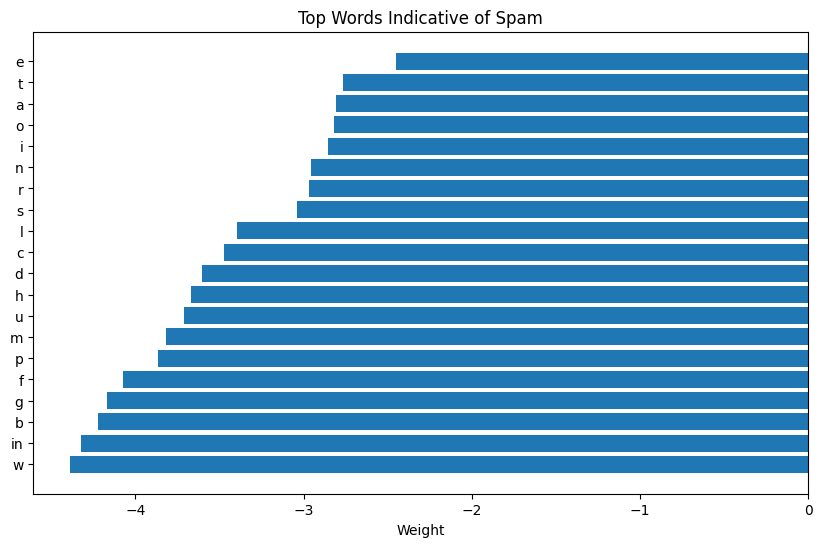

In [21]:
top = importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(top["Word"], top["Weight"])

plt.gca().invert_yaxis()

plt.title("Top Words Indicative of Spam")

plt.xlabel("Weight")

plt.show()

In [22]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

paramGrid = ParamGridBuilder() \
    .addGrid(nb.smoothing,[0.5,1.0,1.5,2.0]) \
    .build()

evaluator = MulticlassClassificationEvaluator(
    labelCol="Prediction",
    predictionCol="prediction",
    metricName="accuracy"
)

tvs = TrainValidationSplit(
    estimator=nb,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.8
)

tuned_model = tvs.fit(train_data)

best_model = tuned_model.bestModel

pred = best_model.transform(test_data)

print(
    "Best Accuracy =",
    evaluator.evaluate(pred)
)

print(
    "Best Smoothing =",
    best_model.getSmoothing()
)

Best Accuracy = 1.0
Best Smoothing = 0.5
